In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
X_t = torch.FloatTensor(X).to(device)
y_t = torch.FloatTensor(data.target).unsqueeze(1).to(device)

In [3]:
def train_model(optimizer_name):
    model = nn.Sequential(nn.Linear(30, 16), nn.ReLU(), nn.Linear(16, 1), nn.Sigmoid()).to(device)
    criterion = nn.BCELoss()
    if optimizer_name == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.01)
    losses = []
    for epoch in range(50):
        optimizer.zero_grad()
        out = model(X_t)
        loss = criterion(out, y_t)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

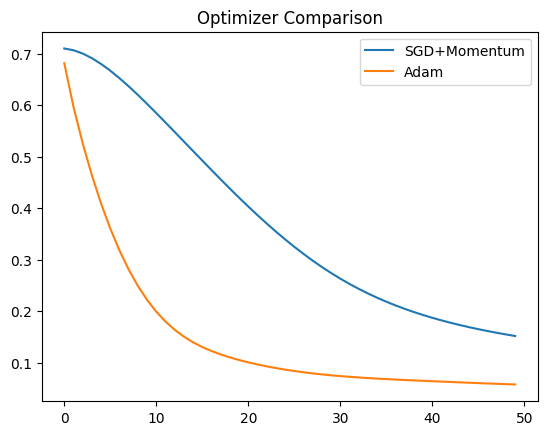

In [4]:
loss_sgd = train_model('sgd')
loss_adam = train_model('adam')
plt.plot(loss_sgd, label='SGD+Momentum')
plt.plot(loss_adam, label='Adam')
plt.legend()
plt.title('Optimizer Comparison')
plt.savefig('optimizer_comparison.png')